In [1]:
import gymnasium as gym
import minari
import matplotlib.pyplot as plt
import numpy as np
import torch
import torch.nn as nn
from torch.utils.data import Dataset, DataLoader, Sampler
from torch.distributions import Bernoulli, Normal
import random
import wandb
from collections import defaultdict
from typing import Self, List, Tuple, Dict, Iterator, Callable
from tqdm import trange, tqdm

%matplotlib inline
wandb.login(key='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')

wandb: WARNING If you're specifying your api key in code, ensure this code is not shared publicly.
wandb: WARNING Consider setting the WANDB_API_KEY environment variable, or running `wandb login` from the command line.
wandb: [wandb.login()] Using explicit session credentials for https://api.wandb.ai.
wandb: Appending key for api.wandb.ai to your netrc file: C:\Users\Kevin\_netrc
wandb: Currently logged in as: kevinqiao-c (muxiqiao) to https://api.wandb.ai. Use `wandb login --relogin` to force relogin


True

In [2]:
env_id: str = 'PointMaze_Open-v3'
dataset_id: str = 'D4RL/pointmaze/open-v2'

In [3]:
class EnvWrapper(gym.ObservationWrapper):
    def __init__(
            self,
            env: gym.Env
        ) -> None:

        super(EnvWrapper, self).__init__(env)

    def observation(
            self,
            observation: Dict[str, np.ndarray]
        ) -> Dict[str, np.ndarray]:

        return {k: v.astype(np.float32) for k, v in observation.items()}

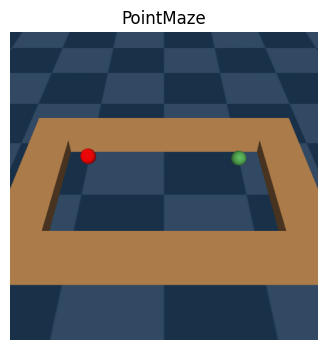

In [4]:
minari_dataset: minari.MinariDataset = minari.load_dataset(dataset_id)
env: gym.Env = EnvWrapper(minari_dataset.recover_environment(render_mode='rgb_array'))
env.reset()

plt.figure(figsize=(4, 4))
plt.imshow(env.render())
plt.title('PointMaze')
plt.axis('off')
plt.show()

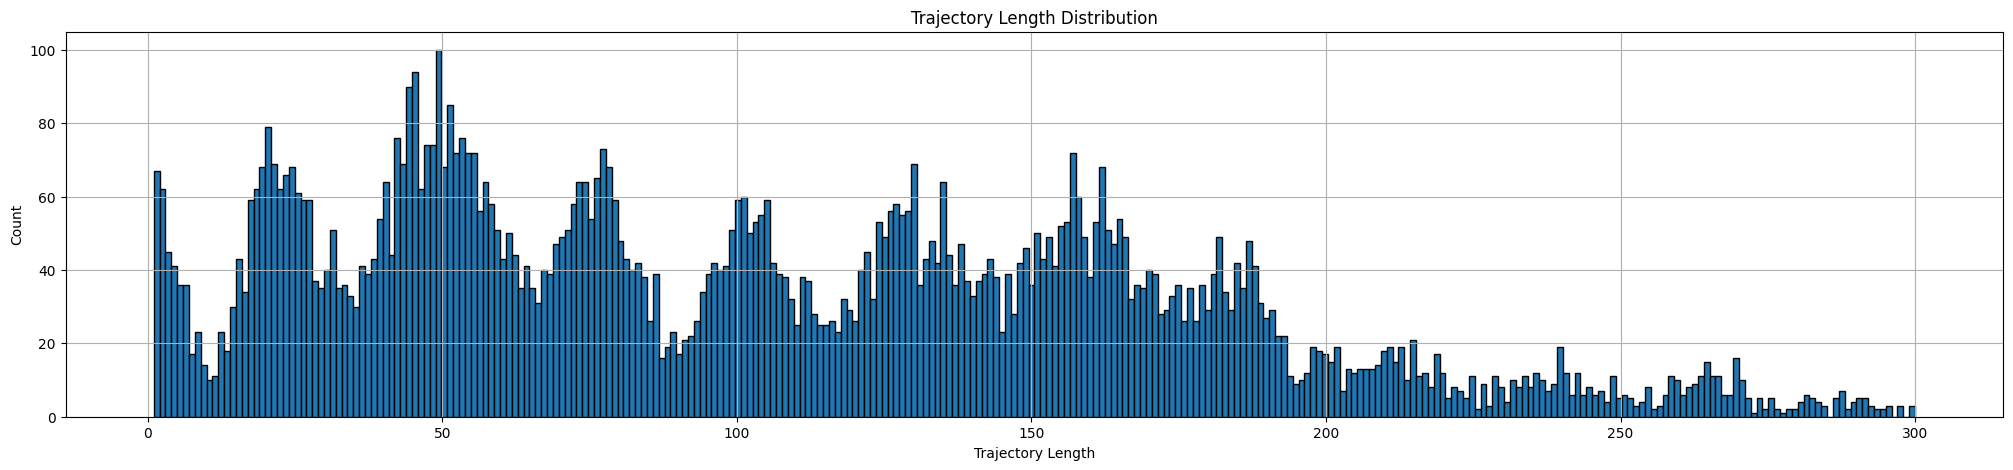

In [5]:
def plot_trajectory_length_histogram(minari_dataset: minari.MinariDataset):
    length = []

    for trajectory in minari_dataset:
        length.append(trajectory.actions.shape[0])

    plt.figure(figsize=(25, 5))
    plt.hist(length, bins=300, edgecolor='black')
    plt.title('Trajectory Length Distribution')
    plt.xlabel('Trajectory Length')
    plt.ylabel('Count')
    plt.grid(True)
    plt.show()

plot_trajectory_length_histogram(minari_dataset)

In [6]:
class EpisodeDataset(Dataset):

    def __init__(self, data: List[Dict[str, torch.Tensor]]) -> None:
        self.data = data

    def __len__(self) -> int:
        return len(self.data)

    def __getitem__(self, idx: int) -> Dict[str, torch.Tensor]:
        ep = self.data[idx]

        return {
            'observations': ep['observations'],
            'actions': ep['actions'],
            'rewards': ep['rewards'],
            'done': ep['done'],
            'goals': ep['goals']
        }

    def get_length(self, idx: int) -> int:
        return self.data[idx]['actions'].shape[0]

    @classmethod
    def create(cls, minari_dataset: minari.MinariDataset, max_length: int = 300, seed=42) -> Self:
        rng = random.Random(seed)
        data = []

        for ep_id in trange(minari_dataset.total_episodes):
            ep = minari_dataset[ep_id]

            observations = ep.observations['achieved_goal']
            actions = ep.actions
            rewards = ep.rewards
            done = ep.truncations
            goals = ep.observations['achieved_goal']

            if len(actions) > max_length:
                random_len = rng.randint(2, max_length)

                observations = ep.observations['achieved_goal'][:random_len + 1]
                actions = ep.actions[:random_len]
                rewards = ep.rewards[:random_len]
                done = ep.truncations[:random_len]
                goals = ep.observations['achieved_goal'][:random_len + 1]

                rewards[-1] = 1
                done[-1] = True

            observations = torch.as_tensor(observations, dtype=torch.float32)
            actions = torch.as_tensor(actions, dtype=torch.float32)
            rewards = torch.as_tensor(rewards, dtype=torch.float32)
            done = torch.as_tensor(done, dtype=torch.float32)
            goals = torch.as_tensor(goals, dtype=torch.float32)

            data.append({
                'observations': observations,
                'actions': actions,
                'rewards': rewards,
                'done': done,
                'goals': goals
            })

        return cls(data)

In [7]:
class GroupByLengthSampler(Sampler):

    def __init__(self, all_batches: List[List[int]]) -> None:
        self.all_batches = all_batches

    def __iter__(self) -> Iterator[List[int]]:
        yield from self.all_batches

    def __len__(self) -> int:
        return len(self.all_batches)

    @staticmethod
    def estimate_batch_size(length: int,
                            base_memory: int,
                            bucket_size: int,
                            max_batch_size: int | None = None) -> int:
        batch_size = min(max((base_memory // (length ** 3 * 4)), 1), bucket_size)

        if max_batch_size is not None:
            batch_size = min(batch_size, max_batch_size)

        return batch_size

    @classmethod
    def create(cls, episode_dataset: EpisodeDataset,
               base_memory: int = 28 * 1024 * 1024,
               max_batch_size: int | None = 16,
               shuffle: bool = False,
               drop_last: bool = False) -> Self:
        length_to_idx = defaultdict(list)
        all_batches = []

        for i in range(len(episode_dataset)):
            length = episode_dataset.get_length(i)
            length_to_idx[length].append(i)

        for length, idx in length_to_idx.items():
            batch_size = cls.estimate_batch_size(length, base_memory, len(idx), max_batch_size)
            if shuffle:
                random.shuffle(idx)

            for i in range(0, len(idx), batch_size):
                batch = idx[i:i + batch_size]
                if drop_last and len(batch) < batch_size:
                    continue
                if len(batch) > 0:
                    all_batches.append(batch)

        if shuffle:
            random.shuffle(all_batches)

        return cls(all_batches)

In [8]:
class MLP(nn.Module):

    def __init__(self, dims: List[int],
                 activation_fn: Callable[[], nn.Module] | None = nn.ReLU,
                 output_activation_fn: Callable[[], nn.Module] | None = None,
                 dropout: float | None = None) -> None:
        super(MLP, self).__init__()

        layers = []
        for i in range(len(dims) - 2):
            layers.append(nn.Linear(dims[i], dims[i + 1]))
            layers.append(activation_fn())

            if dropout is not None:
                layers.append(nn.Dropout(dropout))

        layers.append(nn.Linear(dims[-2], dims[-1]))
        if output_activation_fn is not None:
            layers.append(output_activation_fn())

        self.net = nn.Sequential(*layers)

    def forward(self, x: torch.Tensor) -> torch.Tensor:
        return self.net(x)

In [9]:
class ShouldSplitNet(nn.Module):

    def __init__(self, dims,
                 activation_fn: Callable[[], nn.Module] = nn.ReLU,
                 output_activation_fn: Callable[[], nn.Module] = None,
                 dropout: float = None) -> None:
        super(ShouldSplitNet, self).__init__()

        self.net = MLP(
            dims,
            activation_fn=activation_fn,
            output_activation_fn=output_activation_fn,
            dropout=dropout
        )

    def forward(self, observations: torch.Tensor, goals: torch.Tensor) -> Bernoulli:
        logits = self.net(torch.cat([observations, goals], dim=-1)).squeeze(-1)
        return Bernoulli(logits=logits)

    def compute_terminal_likelihood(self, observations: torch.Tensor, goals: torch.Tensor) -> torch.Tensor:
        B, n = observations.shape[0], observations.shape[1] - 1

        s_i = observations[:, :n].unsqueeze(2).expand(B, n, n, -1)
        g_jp1 = goals[:, 1:].unsqueeze(1).expand(B, n, n, -1)
        terminal = torch.eye(n, dtype=torch.float32, device=observations.device).unsqueeze(0)

        dist = self(s_i, g_jp1)
        T = dist.log_prob(terminal)  # shape: (B, n, n)

        T_mask = torch.triu(torch.ones((n, n), dtype=torch.bool, device=observations.device))
        T = T.masked_fill(~T_mask.unsqueeze(0), -float('inf'))
        return T

    @classmethod
    def create(cls, dims,
               activation_fn: Callable[[], nn.Module] = nn.ReLU,
               output_activation_fn: Callable[[], nn.Module] = None,
               dropout: float = None) -> Self:

        return cls(
            dims=dims,
            activation_fn=activation_fn,
            output_activation_fn=output_activation_fn,
            dropout=dropout
        )

In [10]:
class MidGoalPredictor(nn.Module):

    def __init__(self, dims, activation_fn: Callable[[], nn.Module] = nn.ReLU,
                 output_activation_fn: Callable[[], nn.Module] = None,
                 dropout: float = None) -> None:
        super(MidGoalPredictor, self).__init__()

        self.net = MLP(
            dims=dims,
            activation_fn=activation_fn,
            output_activation_fn=output_activation_fn,
            dropout=dropout
        )
        self.log_std = nn.Parameter(torch.zeros(dims[-1], dtype=torch.float32))

    def forward(self, observations: torch.Tensor, goals: torch.Tensor) -> Normal:
        mean = self.net(torch.cat([observations, goals], dim=-1))
        std = torch.exp(self.log_std.clamp(min=0.0, max=0.0))
        return Normal(mean, std)

    def compute_planed_likelihood(self, observations: torch.Tensor, goals: torch.Tensor) -> torch.Tensor:
        B, n = observations.shape[0], observations.shape[1] - 1

        s_i = observations[:, :n-1].unsqueeze(2).unsqueeze(3).expand(B, n-1, n-1, n-1, -1)            # shape: (B, n-1, n-1, n-1, obs_dim)
        g_jp2 = goals[:, 2:n+1].unsqueeze(1).unsqueeze(3).expand(B, n-1, n-1, n-1, -1)                # shape: (B, n-1, n-1, n-1, goal_dim)
        s_kp1 = observations[:, 1:n].unsqueeze(1).unsqueeze(1)[..., :2].expand(B, n-1, n-1, n-1, -1)  # shape: (B, n-1, n-1, n-1, goal_dim)

        dist = self(s_i, g_jp2)
        P = dist.log_prob(s_kp1).sum(dim=-1)  # shape: (B, n-1, n-1, n-1)

        idx = torch.arange((n - 1), dtype=torch.int64, device=observations.device)
        k, i, j = torch.meshgrid(idx, idx, idx, indexing='ij')
        P_mask = (i <= k) & (k <= j)
        P = P.masked_fill(~P_mask.unsqueeze(0), -float('inf'))
        return P

    @classmethod
    def create(cls, dims,
               activation_fn: Callable[[], nn.Module] = nn.ReLU,
               output_activation_fn: Callable[[], nn.Module] = None,
               dropout: float = None) -> Self:

        return cls(
            dims=dims,
            activation_fn=activation_fn,
            output_activation_fn=output_activation_fn,
            dropout=dropout
        )

In [11]:
class PolicyNet(nn.Module):

    def __init__(self, dims,
                 activation_fn: Callable[[], nn.Module] = nn.ReLU,
                 output_activation_fn: Callable[[], nn.Module] = nn.Tanh,
                 dropout: float = None) -> None:
        super(PolicyNet, self).__init__()

        self.net = MLP(
            dims=dims,
            activation_fn=activation_fn,
            output_activation_fn=output_activation_fn,
            dropout=dropout
        )
        self.log_std = nn.Parameter(torch.zeros(dims[-1], dtype=torch.float32))

    def forward(self, observations: torch.Tensor, goals: torch.Tensor) -> Normal:
        mean = self.net(torch.cat([observations, goals], dim=-1))
        std = torch.exp(self.log_std.clamp(min=0.0, max=0.0))
        return Normal(mean, std)

    def compute_actor_likelihood(self, observations: torch.Tensor, goals: torch.Tensor, actions: torch.Tensor) -> torch.Tensor:
        B, n = observations.shape[0], observations.shape[1] - 1

        s_i = observations[:, :n]  # shape: (B, n, obs_dim)
        g_ip1 = goals[:, 1:]       # shape: (B, n, goal_dim)
        a_i = actions[:, :n]       # shape: (B, n, action_dim)

        dist = self(s_i, g_ip1)
        A = dist.log_prob(a_i).sum(dim=-1)  # shape: (B, n)
        return A

    @classmethod
    def create(cls, dims,
               activation_fn: Callable[[], nn.Module] = nn.ReLU,
               output_activation_fn: Callable[[], nn.Module] = nn.Tanh,
               dropout: float = None) -> Self:

        return cls(
            dims=dims,
            activation_fn=activation_fn,
            output_activation_fn=output_activation_fn,
            dropout=dropout
        )

In [12]:
class PlanningAgent(nn.Module):

    def __init__(self, terminal_dims: List, mid_goal_dims: List, actor_dims: List, max_split_steps: int = 50) -> None:
        super(PlanningAgent, self).__init__()

        self.terminal = ShouldSplitNet.create(terminal_dims)
        self.mid_goal = MidGoalPredictor.create(mid_goal_dims)
        self.actor = PolicyNet.create(actor_dims)
        self.max_split_steps = max_split_steps

    def act_agent(self, observations: torch.Tensor, goals: torch.Tensor) -> Tuple[torch.Tensor, List[torch.Tensor]]:
        split_step = 1
        mid_goal_list = [goals]

        while self.terminal(observations, goals).mean < 0.5:
            if split_step >= self.max_split_steps:
                break

            split_step += 1
            goal = self.mid_goal(observations, goals).mean
            mid_goal_list.append(goal)

        mid_goal_list.reverse()

        return self.actor(observations, goals).mean, mid_goal_list

In [13]:
def compute_total_likelihood(A: torch.Tensor,  # shape: (B, n)
                             T: torch.Tensor,  # shape: (B, n, n)
                             P: torch.Tensor,  # shape: (B, n-1, n-1, n-1)
                             use_optimal_path: bool = True) -> Tuple[torch.Tensor, torch.Tensor, torch.Tensor]:
    B, n = A.shape
    L = torch.full((B, n, n), -float('inf'), dtype=torch.float32, device=A.device)
    optimal_idx = torch.full((B, n, n), -1, dtype=torch.int64, device=A.device) if use_optimal_path else None
    tree_depth = torch.full((B, n, n), 1, dtype=torch.int64, device=A.device)

    diag = torch.arange(n, dtype=torch.int64, device=A.device)
    L[:, diag, diag] = A + T[:, diag, diag]

    for d in range(1, n):
        i = torch.arange(n - d, dtype=torch.int64, device=A.device)
        j = i + d
        k = i[:, None] + torch.arange(d, dtype=torch.int64, device=A.device)[None, :]  # shape: (n-d, d)

        # Shape: (B, n-d, d)
        p_mid = P[:, k, i[:, None], j[:, None] - 1]           # shape: (B, n-d, d)
        l1 = L[:, i[:, None], k]                              # shape: (B, n-d, d)
        l2 = L[:, k + 1, j[:, None]]                          # shape: (B, n-d, d)

        log_terms = p_mid + l1 + l2                           # shape: (B, n-d, d)

        if use_optimal_path:
            optimal, argmax_k = torch.max(log_terms, dim=2)
            L[:, i, j] = T[:, i, j] + optimal

            abs_k = i.unsqueeze(0) + argmax_k                # shape: (B, n-d)
            optimal_idx[:, i, j] = abs_k

            b_idx = torch.arange(B, dtype=torch.int64, device=A.device)[:, None]            # shape: (B, 1)
            i_idx = i[None, :]
            j_idx = j[None, :]
            left_depth = tree_depth[b_idx, i_idx, abs_k]
            right_depth = tree_depth[b_idx, abs_k, j_idx]
            depth = torch.maximum(left_depth, right_depth) + 1
            tree_depth[:, i, j] = depth
        else:
            L[:, i, j] = T[:, i, j] + torch.logsumexp(log_terms, dim=2)

    return L, optimal_idx, tree_depth                         # shape: (B, n, n)

In [14]:
def recover_optimal_trajectory(goal: torch.Tensor, optimal_idx: torch.Tensor) -> Tuple[List[torch.Tensor], List[Dict]]:
    B, n = goal.shape[0], goal.shape[1] - 1
    optimal_paths = []
    tree_structures = []

    def build_tree(idx: torch.Tensor, i: int, j: int) -> None | Dict:
        k = idx[i, j].item()
        if k == -1:
            return None
        node = {
            'idx': k + 1,
            'left': build_tree(idx, i, k) if k >= i else None,
            'right': build_tree(idx, k + 1, j) if k + 1 <= j else None
        }
        return node

    def inorder_traverse(tree: None | Dict) -> List[int]:
        if tree is None:
            return []
        return inorder_traverse(tree['left']) + [tree['idx']] + inorder_traverse(tree['right'])

    for b in range(B):
        idx = optimal_idx[b]
        tree = build_tree(idx, 0, n - 1)
        tree_structures.append(tree)

        mid_goal_idx = inorder_traverse(tree)
        mid_goals = [goal[b, m] for m in mid_goal_idx]
        trajectory = torch.stack([goal[b, 0]] + mid_goals + [goal[b, -1]], dim=0)
        optimal_paths.append(trajectory)

    return optimal_paths, tree_structures

In [15]:
def compute_mid_goal_achieved(trajectory_info: List[Dict[str, np.ndarray]],
                              mid_goal_list_info: List[List[torch.Tensor]],
                              max_split_step: int = 50,
                              threshold: float = 0.45) -> Tuple[List[int], List[int]]:
    n_level_goal_achieved = [0] * max_split_step
    n_level_goal_counts = [0] * max_split_step

    for i, mid_goal_list in enumerate(mid_goal_list_info[:-1]):
        mid_goal = [mg.detach().cpu().numpy() for mg in mid_goal_list]
        trajectory_achieved_goal = [step['achieved_goal'] for step in trajectory_info[i + 1:]]

        for j in range(len(mid_goal_list)):
            n_level_goal_counts[j] += 1

        if float(np.linalg.norm(trajectory_achieved_goal[0] - mid_goal[0])) < threshold:
            n_level_goal_achieved[0] += 1

            target_idx = 1
            for achieved_goal in trajectory_achieved_goal[1:]:
                if target_idx >= len(mid_goal):
                    break

                if float(np.linalg.norm(achieved_goal - mid_goal[target_idx])) < threshold:
                    n_level_goal_achieved[target_idx] += 1
                    target_idx += 1

    return n_level_goal_achieved, n_level_goal_counts

In [16]:
def evaluate(agent: PlanningAgent,
             env: gym.Env,
             epoches: int = 10,
             use_wandb: bool = True,
             device: str = 'cpu') -> Tuple[np.floating, np.floating, np.floating, np.floating, List[np.floating], List[np.floating]]:

    agent.eval()

    step_info = []
    reward_info = []
    norm_total_reward_info = []
    success_rate_info = []

    with tqdm(iterable=range(epoches), leave=False, dynamic_ncols=True) as pbar:
        for epoch in pbar:
            trajectory_info = []
            mid_goal_list_info = []

            obs_dict, info = env.reset()
            obs = torch.tensor(obs_dict['achieved_goal'], device=device)
            goal = torch.tensor(obs_dict['desired_goal'], device=device)
            done = info['success']
            total_reward = 0.0
            roll_step = 0

            while not done:
                with torch.no_grad():
                    action, mid_goal_list = agent.act_agent(obs, goal)
                    obs_dict, reward, terminated, truncated, info = env.step(action.cpu().numpy())
                    obs = torch.tensor(obs_dict['achieved_goal'], device=device)
                    goal = torch.tensor(obs_dict['desired_goal'], device=device)
                    done = info['success'] or truncated
                    total_reward += reward
                    roll_step += 1

                    if roll_step >= 300:
                        done = True

                    trajectory_info.append(obs_dict)
                    mid_goal_list_info.append(mid_goal_list)

            norm_total_reward = (total_reward - 23.85) / (161.86 - 23.85)
            n_level_goal_achieved, n_level_goal_counts = compute_mid_goal_achieved(trajectory_info, mid_goal_list_info)
            success_rate = [float(g / c) if c != 0 else 0 for g, c in zip(n_level_goal_achieved, n_level_goal_counts)]
            success_rate_info.append(success_rate)

            if use_wandb:
                wandb.log({
                    **{
                        'Test/Roll Step': roll_step,
                        'Test/Total Reward': total_reward,
                        'Test/Norm Total Reward': norm_total_reward
                    },
                    **{f'Test/Success Rate/Depth_{i + 1}': v for i, v in enumerate(success_rate)}
                })

            pbar.set_description(f'Testing Epoch: {epoch + 1} / {epoches}, Mean = {np.nanmean(reward_info) if reward_info else 0:.9f}, Std = {np.nanstd(reward_info) if reward_info else 0:.9f}')

            step_info.append(roll_step)
            reward_info.append(total_reward)
            norm_total_reward_info.append(norm_total_reward)

    return np.nanmean(reward_info), np.nanstd(reward_info), np.nanmean(norm_total_reward_info), np.nanstd(norm_total_reward_info), np.nanmean(success_rate_info, axis=0), np.nanstd(success_rate_info, axis=0)

In [17]:
def train(agent: PlanningAgent,
          env: gym.Env,
          dataloader: DataLoader,
          optimizer: torch.optim.Optimizer | None = None,
          use_wandb: bool = True,
          lr: float = 1e-4,
          weight_decay: float = 1e-5,
          train_epochs: int = 100,
          log_interval: int = 10,
          planner_save_path: str = 'open_maze_planner.pt',
          device: str = 'cpu') -> Tuple[List[torch.Tensor], List[torch.Tensor], List[torch.Tensor]]:

    if use_wandb:
        wandb.init(
            mode='online',
            project='Open Maze Training',
            name='Open Maze Training Baseline',
            config={
                'lr': lr,
                'weight_decay': weight_decay,
                'epochs': train_epochs,
                'log_interval': log_interval
            }
        )

    if optimizer is None:
        optimizer = torch.optim.Adam(
            agent.parameters(),
            lr=lr,
            weight_decay=weight_decay
        )

    agent.train()

    step = 0
    total_loss = 0.0
    total_trajectory = 0
    log_L = []
    log_optimal_idx = []
    log_tree_depth = []

    for epoch in range(train_epochs):
        with tqdm(iterable=dataloader, leave=False, dynamic_ncols=True) as pbar:
            for batch in pbar:
                batch = {k: v.to(device) for k, v in batch.items()}

                obs = batch['observations']          # shape: (B, n+1, obs_dim)
                action = batch['actions']            # shape: (B, n, action_dim)
                goal = batch['goals']                # shape: (B, n+1, goal_dim)
                B, n = obs.shape[0], obs.shape[1] - 1

                A = agent.actor.compute_actor_likelihood(obs, goal, action)         # shape: (B, n)
                T = agent.terminal.compute_terminal_likelihood(obs, goal)           # shape: (B, n, n)
                P = agent.mid_goal.compute_planed_likelihood(obs, goal)             # shape: (B, n-1, n-1, n-1)

                actor_loss = -A.mean()

                T_mask = torch.triu(torch.ones(n, n, dtype=torch.bool, device=device)).unsqueeze(0)  # shape: (1, n, n)
                T_ref = T[T_mask.expand(B, -1, -1)]
                terminal_loss = -T_ref.mean()

                L, optimal_idx, tree_depth = compute_total_likelihood(A, T, P)      # shape: (B, n, n)
                log_L.append(L)
                log_optimal_idx.append(optimal_idx)
                log_tree_depth.append(tree_depth)

                n = L.shape[1]
                loss = -L[:, 0, n-1].mean() / n                                     # L[0, n-1] maximize likelihood

                total_loss += loss.item() * B
                total_trajectory += B
                average_loss = total_loss / total_trajectory

                optimizer.zero_grad()
                loss.backward()
                actor_grad = nn.utils.clip_grad_norm_(parameters=agent.actor.parameters(), max_norm=1, norm_type=2)
                terminal_grad = nn.utils.clip_grad_norm_(parameters=agent.terminal.parameters(), max_norm=1, norm_type=2)
                mid_goal_grad = nn.utils.clip_grad_norm_(parameters=agent.mid_goal.parameters(), max_norm=1, norm_type=2)
                optimizer.step()

                pbar.set_description(f'Training Epoch: {epoch + 1} / {train_epochs}, Step {step}: Current Loss = {loss.item():.9f}, Average loss = {average_loss:.9f}')
                if use_wandb and step % log_interval == 0:
                    wandb.log({
                        'Train/Current Loss': loss.item(),
                        'Train/Average Loss': average_loss,
                        'Train/Actor Loss': actor_loss.item(),
                        'Train/Terminal Loss': terminal_loss.item(),
                        'Train/Actor Grad': actor_grad,
                        'Train/Terminal Grad': terminal_grad,
                        'Train/Mid Goal Grad': mid_goal_grad
                    }, step=step)
                step += 1

            mean, std, norm_mean, norm_std, success_mean, success_std = evaluate(agent, env, device=device)
            if use_wandb:
                wandb.log({
                    **{
                        'Test/Mean': mean,
                        'Test/Std': std,
                        'Test/Norm Mean': norm_mean,
                        'Test/Norm Std': norm_std
                    },
                    **{f'Test/Success Mean/Depth_{i + 1}': v for i, v in enumerate(success_mean)},
                    **{f'Test/Success Std/Depth_{i + 1}': v for i, v in enumerate(success_std)}
                }, step=step)

    wandb.finish()

    agent.eval()
    torch.save(agent.state_dict(), planner_save_path)
    print(f'Saved planner model to {planner_save_path}')

    torch.save(log_L, 'log_l.pt')
    torch.save(log_optimal_idx, 'log_optimal_idx.pt')
    torch.save(log_tree_depth, 'log_tree_depth.pt')
    print('Saved all log files.')

    return log_L, log_optimal_idx, log_tree_depth

In [18]:
device: str = 'cuda' if torch.cuda.is_available() else 'mps' if torch.backends.mps.is_available() else 'cpu'

episode_dataset: EpisodeDataset = EpisodeDataset.create(minari_dataset, max_length=120)
episode_data_loader: DataLoader = DataLoader(episode_dataset, batch_sampler=GroupByLengthSampler.create(episode_dataset, base_memory=(28 * 1024 * 1024)))

print(f'Device: {device}')

obs_dim = episode_dataset[0]['observations'].shape[-1]
action_dim = episode_dataset[0]['actions'].shape[-1]
goal_dim = episode_dataset[0]['goals'].shape[-1]

100%|██████████| 9525/9525 [00:09<00:00, 952.79it/s]


Device: cuda


In [19]:
agent: PlanningAgent = PlanningAgent([(obs_dim + goal_dim), 16, 32, 16, 1], [(obs_dim + goal_dim), 16, 32, 16, goal_dim], [(obs_dim + goal_dim), 16, 32, 16, action_dim]).to(device=device)
log_L, log_optimal_idx, log_tree_depth = train(agent, env, episode_data_loader, device=device, train_epochs=50)

Training Epoch: 2 / 50, Step 688: Current Loss = 6.011085510, Average loss = 6.323857402:  10%|█         | 65/624 [00:09<01:37,  5.74it/s] wandb: WARNING Tried to log to step 624 that is less than the current step 630. Steps must be monotonically increasing, so this data will be ignored. See https://wandb.me/define-metric to log data out of order.
Training Epoch: 3 / 50, Step 1261: Current Loss = 5.324974537, Average loss = 6.085577792:   2%|▏         | 14/624 [00:01<01:30,  6.74it/s] wandb: WARNING Tried to log to step 1248 that is less than the current step 1250. Steps must be monotonically increasing, so this data will be ignored. See https://wandb.me/define-metric to log data out of order.
Training Epoch: 4 / 50, Step 1924: Current Loss = 5.071267605, Average loss = 5.854788539:   8%|▊         | 53/624 [00:07<01:13,  7.77it/s] wandb: WARNING Tried to log to step 1872 that is less than the current step 1880. Steps must be monotonically increasing, so this data will be ignored. See h

Test/Mean,▁▁▁████▅▅█
Test/Norm Mean,▁▁▁████▅▅█
Test/Norm Std,▁▁▁████▆▆█
Test/Norm Total Reward,▁▁▁▁▁▁▁▁▁█▁▁▁▁▁▁▁▁▁▁▁▁▁▁▁█▁██▁▁█▁▁▁▁▁▁▁▁
Test/Roll Step,█████▂███████████████████▅██████▁▁██▁██▁
Test/Std,▁▁▁████▆▆█
Test/Success Mean/Depth_1,▂▅▅▁▅▄▆█▆▇
Test/Success Mean/Depth_10,▁▆▅▁▄▂▃█▄▆
Test/Success Mean/Depth_11,▁▆▅▁▃▂▃█▄▆
Test/Success Mean/Depth_12,▁▆▅▁▃▂▃█▅▆
+154,...


Saved planner model to open_maze_planner.pt
Saved all log files.


In [20]:
print(len(episode_dataset))
print(len(minari_dataset))

9525
9525


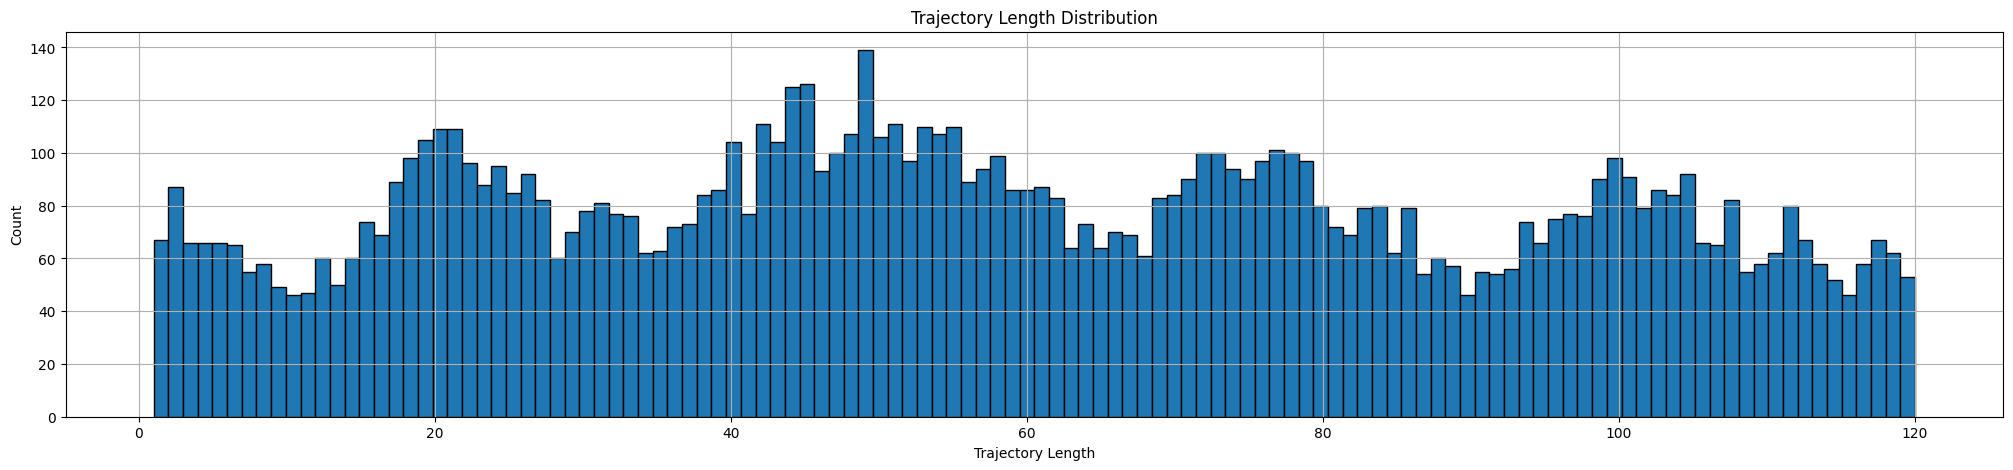

In [21]:
def plot_trajectory_length_histogram(episode_dataset: EpisodeDataset):
    length = []

    for trajectory in episode_dataset:
        length.append(trajectory['actions'].shape[0])

    plt.figure(figsize=(25, 5))
    plt.hist(length, bins=120, edgecolor='black')
    plt.title('Trajectory Length Distribution')
    plt.xlabel('Trajectory Length')
    plt.ylabel('Count')
    plt.grid(True)
    plt.show()

plot_trajectory_length_histogram(episode_dataset)

In [22]:
def test_batch_size_scheduler(max_len: int = 120, base_memory: int = 28 * 1024 * 1024):
    print(f'{"n":>5} | {"Estimated Batch Size":>20} | {"Est. Mem per traj (MB)":>25}')
    print('-' * 60)
    for length in range(1, max_len + 1):
        est_per_traj = (length ** 3 * 4) / 1024
        batch_size = max(base_memory // (length ** 3 * 4), 1)
        print(f'{length:>5} | {batch_size:>20} | {est_per_traj:>25.2f}')

test_batch_size_scheduler()

    n | Estimated Batch Size |    Est. Mem per traj (MB)
------------------------------------------------------------
    1 |              7340032 |                      0.00
    2 |               917504 |                      0.03
    3 |               271853 |                      0.11
    4 |               114688 |                      0.25
    5 |                58720 |                      0.49
    6 |                33981 |                      0.84
    7 |                21399 |                      1.34
    8 |                14336 |                      2.00
    9 |                10068 |                      2.85
   10 |                 7340 |                      3.91
   11 |                 5514 |                      5.20
   12 |                 4247 |                      6.75
   13 |                 3340 |                      8.58
   14 |                 2674 |                     10.72
   15 |                 2174 |                     13.18
   16 |                 179